# **Car Purchase Propensity Prediction - Aplicando SVM**

Projeto da EBAC da Machine Learning para identificação de clientes com maior probabilidade de compra de veículos, envolvendo análise exploratória, tratamento de dados, treinamento e comparação entre modelos SVM e XGBoost, com avaliação por métricas de classificação e análise de performance.



In [1]:
from sklearn.svm import SVC
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [2]:
# Carregando os tipos de dados
df = pd.read_csv('CARRO_CLIENTES.csv')
df.head()

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


In [3]:
# Verificar os tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [4]:
# Verificar os dados faltantes
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
AnnualSalary,0
Purchased,0


In [5]:
# dropar a coluna User ID
df.drop('User ID', axis=1, inplace=True)
df.head()

,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0


# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [6]:
# Aplicar Label Encoder para coluna Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df.head()

,Gender,Age,AnnualSalary,Purchased
0,1,35,20000,0
1,1,40,43500,0
2,1,49,74000,0
3,1,40,107500,1
4,1,25,79000,0


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

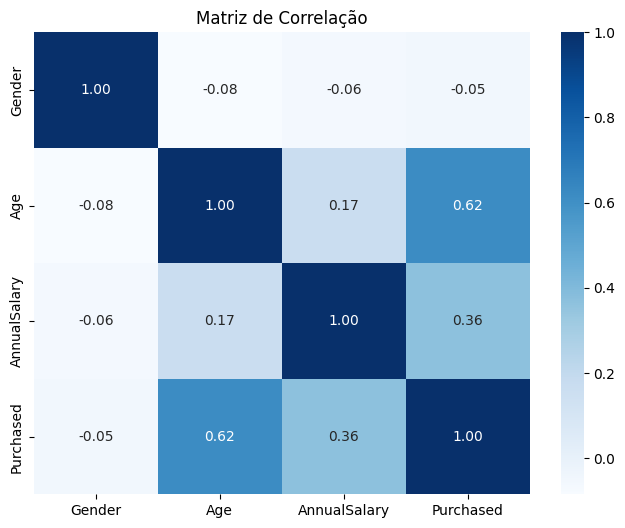

In [7]:
# Matriz de correlação
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='Blues',
    fmt='.2f'
)
plt.title('Matriz de Correlação')
plt.show()

A análise da matriz de correlação indicou que a variável *Age* apresentou a maior associação linear com a variável target *Purchased* (0.62), seguida da *AnnualSalary*(0.36). Isso significa que a renda anual e a idade podem influenciar a propensão à compra de veículos.

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [8]:
# Separação da base em X e Y
X = df.drop('Purchased', axis=1)
Y = df['Purchased']

**Todos passos até aqui vocês realizaram na tarefa anterior também!**

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


# 5. Treino o modelo SVM com sua base de treino.
Esse modelo deve ser treinado usando o kernel linear.

In [10]:
# Antes de treinar o modelo eu irei padronizar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# Treinar o modelo SVM
svm_linear = SVC(kernel='linear', random_state=1, C=0.1)
svm_linear.fit(X_train, Y_train)

SVC(C=0.1, kernel='linear', random_state=1)

# 6. Realize as previsões para a base de teste e traga a avaliação.

In [12]:
# Realizar previsões para a base de teste
Y_pred = svm_linear.predict(X_test)

print ("Acurácia:", accuracy_score(Y_test, Y_pred))

print ("\nRelatória de Classificação:")
print (classification_report(Y_test, Y_pred))

print ("\nMatrix de Confusão:")
print (confusion_matrix(Y_test, Y_pred))

Acurácia: 0.805

Relatória de Classificação:
              precision    recall  f1-score   support

           0       0.76      0.95      0.84       112
           1       0.90      0.62      0.74        88

    accuracy                           0.81       200
   macro avg       0.83      0.79      0.79       200
weighted avg       0.82      0.81      0.80       200


Matrix de Confusão:
[[106   6]
 [ 33  55]]


# 7. Treine um novo modelo SVM com sua base de treino + realize as previsões e avalições.
Esse modelo dedve ser treinado usando o kernel poly.

In [13]:
# Treinar o modelo SVM
svm_poly = SVC(kernel='poly', random_state=1, C=0.1)
svm_poly.fit(X_train, Y_train)

SVC(C=0.1, kernel='poly', random_state=1)

In [14]:
# Realizar as previsões para a base de teste
Y_pred = svm_poly.predict(X_test)

print ("Acurácia:", accuracy_score(Y_test, Y_pred))

print ("\nRelatória de Classificação:")
print (classification_report(Y_test, Y_pred))

print ("\nMatrix de Confusão:")
print (confusion_matrix(Y_test, Y_pred))

Acurácia: 0.795

Relatória de Classificação:
              precision    recall  f1-score   support

           0       0.74      0.98      0.84       112
           1       0.96      0.56      0.71        88

    accuracy                           0.80       200
   macro avg       0.85      0.77      0.77       200
weighted avg       0.84      0.80      0.78       200


Matrix de Confusão:
[[110   2]
 [ 39  49]]


# 8. Qual modelo se saiu melhor? O SVM com kernel linear ou poly? Compare também com o XGboost, da atividade anterior, você obteve melhores previsões com qual dos modelos?

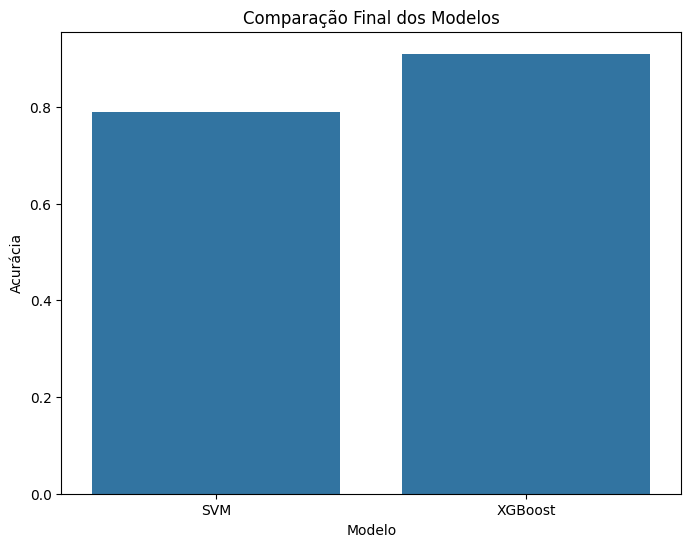

In [16]:
resultados = pd.DataFrame({
    'Modelo': ['SVM', 'XGBoost'],
    'Acurácia': [0.79, 0.91]

})
plt.figure(figsize=(8,6))
sns.barplot(x='Modelo', y='Acurácia', data=resultados)
plt.title('Comparação Final dos Modelos')
plt.xlabel('Modelo')
plt.ylabel('Acurácia')
plt.savefig('resultados.png', dpi=300, bbox_inches='tight')
plt.show()

Os resultados mostraram que técnicas de Machine Learning podem ser eficazes para identificar clientes com maior propensão de compra de veículos, permitindo apoiar estratégias comerciais mais assertivas.

Ao longo do projeto, foram realizadas etapas de análise exploratória, tratamento de dados, modelagem preditiva e comparação entre algoritmos.

Na avaliação final, o modelo XGBoost apresentou melhor desempenho em relação ao SVM, demonstrando maior capacidade preditiva para este conjunto de dados.

Além da performance superior, a análise de importância das variáveis permitiu identificar os fatores mais relevantes para a tomada de decisão, reforçando o potencial do uso de dados para otimização de campanhas de vendas e segmentação de clientes.